# 1. Setup and Imports

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import re
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 2. Data Preprocessing




In [5]:
def clean_text(text):
    """Clean text for BERT inspired by the provided notebook."""
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [6]:
cols = ['id', 'entity', 'sentiment', 'text']
train_df = pd.read_csv('twitter_training.csv', names=cols).dropna(subset=['text'])
val_full_df = pd.read_csv('twitter_validation.csv', names=cols).dropna(subset=['text'])

train_df['text'] = train_df['text'].apply(clean_text)
val_full_df['text'] = val_full_df['text'].apply(clean_text)

label_map = {val: i for i, val in enumerate(train_df['sentiment'].unique())}
train_df['label'] = train_df['sentiment'].map(label_map)
val_full_df['label'] = val_full_df['sentiment'].map(label_map)

val_df, test_df = train_test_split(val_full_df, test_size=0.5, random_state=42, stratify=val_full_df['label'])

print(f"Data Loaded. Classes: {label_map}")

Data Loaded. Classes: {'Positive': 0, 'Neutral': 1, 'Negative': 2, 'Irrelevant': 3}


# 3. Tokenization and Dataset

In [7]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

class TwitterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        encoding = tokenizer(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# 4. Training Functions

In [8]:
def train_epoch(model, dataloader, optimizer, scheduler):

    model.train()
    total_loss = 0

    for batch in dataloader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask=mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


# 5. Evaluation Function

In [9]:
def evaluate(model, dataloader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)

            outputs = model(input_ids, attention_mask=mask)

            preds = torch.argmax(outputs.logits, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(batch["labels"].numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_map.keys(),
        yticklabels=label_map.keys()
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# 6. EXPERIMENT FUNCTION

In [10]:
def run_experiment(model_name, mode="full_finetune"):

    print("\n==============================")
    print("MODEL:", model_name)
    print("MODE :", mode)
    print("==============================")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_map)
    )

    # FREEZING STRATEGIES
    if mode == "freeze_all":

        for param in model.base_model.parameters():
            param.requires_grad = False

    elif mode == "fine_tune_last_2":

        for param in model.base_model.parameters():
            param.requires_grad = False

        if hasattr(model.base_model, "encoder"):
            for layer in model.base_model.encoder.layer[-2:]:
                for param in layer.parameters():
                    param.requires_grad = True

    model.to(device)

    # DATALOADERS
    train_loader = DataLoader(
        TwitterDataset(train_df["text"], train_df["label"], tokenizer),
        batch_size=16,
        shuffle=True
    )

    val_loader = DataLoader(
        TwitterDataset(val_df["text"], val_df["label"], tokenizer),
        batch_size=16
    )

    test_loader = DataLoader(
        TwitterDataset(test_df["text"], test_df["label"], tokenizer),
        batch_size=16
    )

    optimizer = AdamW(model.parameters(), lr=2e-5)

    total_steps = len(train_loader) * 2

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    # TRAINING
    for epoch in range(2):

        model.train()
        total_loss = 0

        for batch in train_loader:

            optimizer.zero_grad()

            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                ids,
                attention_mask=mask,
                labels=labels
            )

            loss = outputs.loss

            loss.backward()

            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

        print("Validation Performance:")
        evaluate(model, val_loader)

    print("\nFinal Test Performance:")
    evaluate(model, test_loader)


MODEL: bert-base-uncased
MODE : freeze_all


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.3599663301931846
Validation Performance:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Accuracy : 0.386
Precision: 0.33724502706595727
Recall   : 0.386
F1 Score : 0.34076993099161146

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.47      0.45       138
           1       0.45      0.27      0.34       143
           2       0.34      0.67      0.45       133
           3       0.00      0.00      0.00        86

    accuracy                           0.39       500
   macro avg       0.30      0.35      0.31       500
weighted avg       0.34      0.39      0.34       500



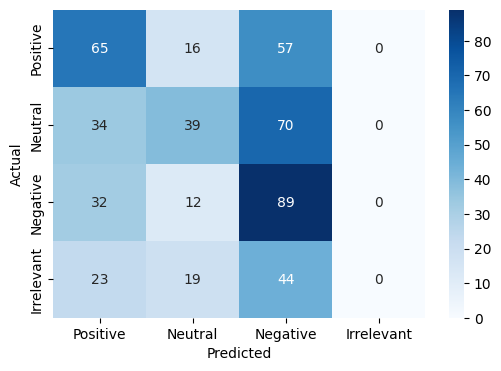

Epoch 2 Loss: 1.3430753949397318
Validation Performance:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Accuracy : 0.39
Precision: 0.34574119688019733
Recall   : 0.39
F1 Score : 0.34593812048192774

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.37      0.41       138
           1       0.45      0.34      0.39       143
           2       0.34      0.72      0.46       133
           3       0.00      0.00      0.00        86

    accuracy                           0.39       500
   macro avg       0.31      0.36      0.31       500
weighted avg       0.35      0.39      0.35       500



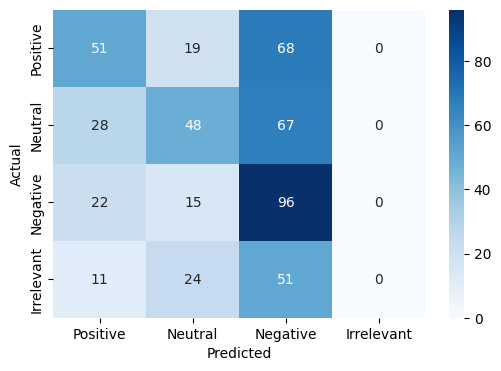


Final Test Performance:

Accuracy : 0.42
Precision: 0.38590853353353355
Recall   : 0.42
F1 Score : 0.374489650700177

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.40      0.45       139
           1       0.53      0.36      0.43       142
           2       0.35      0.78      0.48       133
           3       0.00      0.00      0.00        86

    accuracy                           0.42       500
   macro avg       0.35      0.38      0.34       500
weighted avg       0.39      0.42      0.37       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

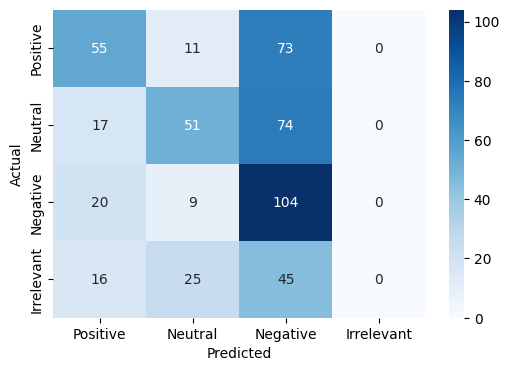

In [11]:
run_experiment("bert-base-uncased", "freeze_all")


MODEL: bert-base-uncased
MODE : fine_tune_last_2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.0311300113007829
Validation Performance:

Accuracy : 0.694
Precision: 0.6916701196842374
Recall   : 0.694
F1 Score : 0.6867047047276473

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.74      0.71       138
           1       0.67      0.56      0.61       143
           2       0.72      0.89      0.80       133
           3       0.70      0.53      0.61        86

    accuracy                           0.69       500
   macro avg       0.69      0.68      0.68       500
weighted avg       0.69      0.69      0.69       500



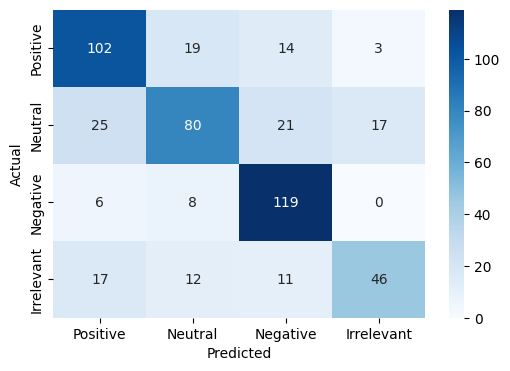

Epoch 2 Loss: 0.871040139256297
Validation Performance:

Accuracy : 0.734
Precision: 0.7325339063674347
Recall   : 0.734
F1 Score : 0.7302007413413645

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       138
           1       0.73      0.63      0.67       143
           2       0.75      0.89      0.81       133
           3       0.71      0.63      0.67        86

    accuracy                           0.73       500
   macro avg       0.73      0.73      0.73       500
weighted avg       0.73      0.73      0.73       500



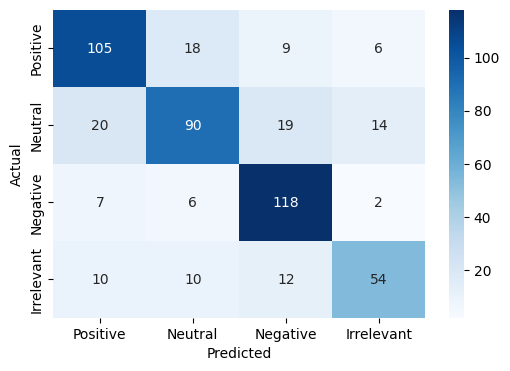


Final Test Performance:

Accuracy : 0.732
Precision: 0.7329590508939593
Recall   : 0.732
F1 Score : 0.7268464227219263

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.83      0.78       139
           1       0.76      0.65      0.70       142
           2       0.71      0.85      0.77       133
           3       0.71      0.53      0.61        86

    accuracy                           0.73       500
   macro avg       0.73      0.71      0.72       500
weighted avg       0.73      0.73      0.73       500



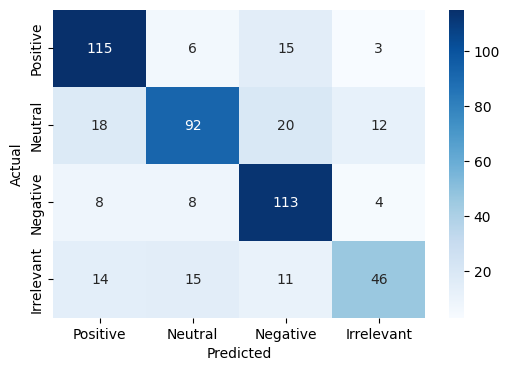

In [12]:
run_experiment("bert-base-uncased", "fine_tune_last_2")


MODEL: distilbert-base-uncased
MODE : full_finetune


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.788594284542509
Validation Performance:

Accuracy : 0.91
Precision: 0.9144825770467008
Recall   : 0.91
F1 Score : 0.9100588699181706

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       138
           1       0.94      0.85      0.89       143
           2       0.97      0.94      0.95       133
           3       0.91      0.87      0.89        86

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



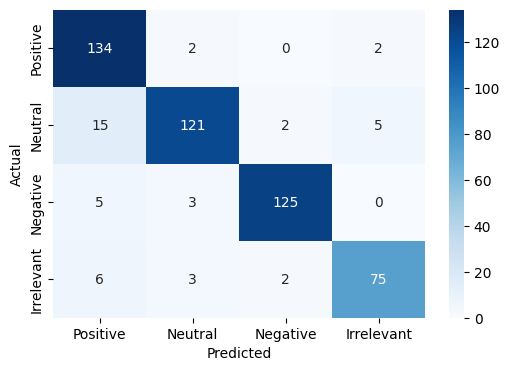

Epoch 2 Loss: 0.3217616140743768
Validation Performance:

Accuracy : 0.948
Precision: 0.9481945880206749
Recall   : 0.948
F1 Score : 0.9479288256227758

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       138
           1       0.96      0.92      0.94       143
           2       0.95      0.95      0.95       133
           3       0.94      0.94      0.94        86

    accuracy                           0.95       500
   macro avg       0.95      0.95      0.95       500
weighted avg       0.95      0.95      0.95       500



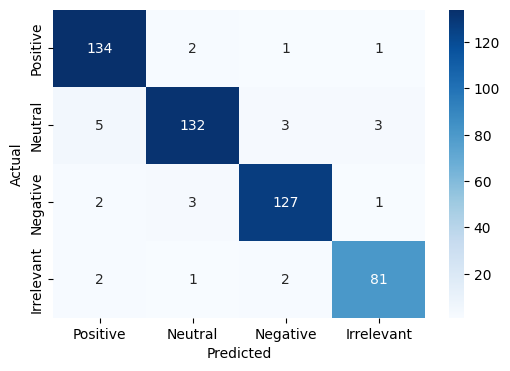


Final Test Performance:

Accuracy : 0.964
Precision: 0.9648213317024845
Recall   : 0.964
F1 Score : 0.964157329823728

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       139
           1       0.94      0.97      0.96       142
           2       0.99      0.97      0.98       133
           3       0.93      0.97      0.95        86

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



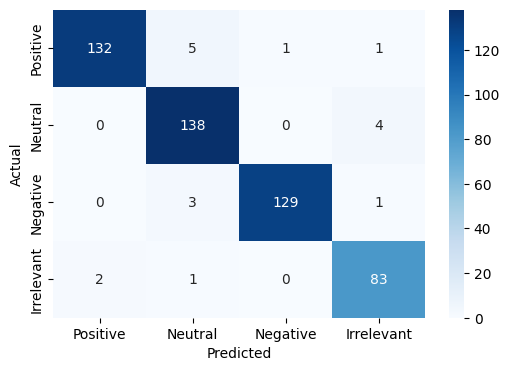

In [13]:
run_experiment("distilbert-base-uncased", "full_finetune")